In [2]:
%run radarSingalProcessingHelper.ipynb 
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 10, 'axes.titlesize': 12,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 12,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
})

In [3]:
all_channel_response = []

SAMPLING_RATE = 5e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '../script/'
prefix = 'freeSpace_0'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_0, calibrated_channel_response_0, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

all_channel_response.append(calibrated_channel_response_0)

prefix = 'freeSpace_1'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_1, calibrated_channel_response_1, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

all_channel_response.append(calibrated_channel_response_1)

prefix = 'freeSpace_2'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_2, calibrated_channel_response_2, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

all_channel_response.append(calibrated_channel_response_2)

prefix = 'freeSpace_3'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_3, calibrated_channel_response_3, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)



all_channel_response.append(calibrated_channel_response_3)

signal_power:  3.0960027200332267
average_noise_power:  0.004127209200348224
28.751448504680297
signal_power:  0.18296274735553972
average_noise_power:  0.0004511566017489116
26.080353552632896
signal_power:  0.04489111364301288
average_noise_power:  0.00013251518772964865
25.29894719929831


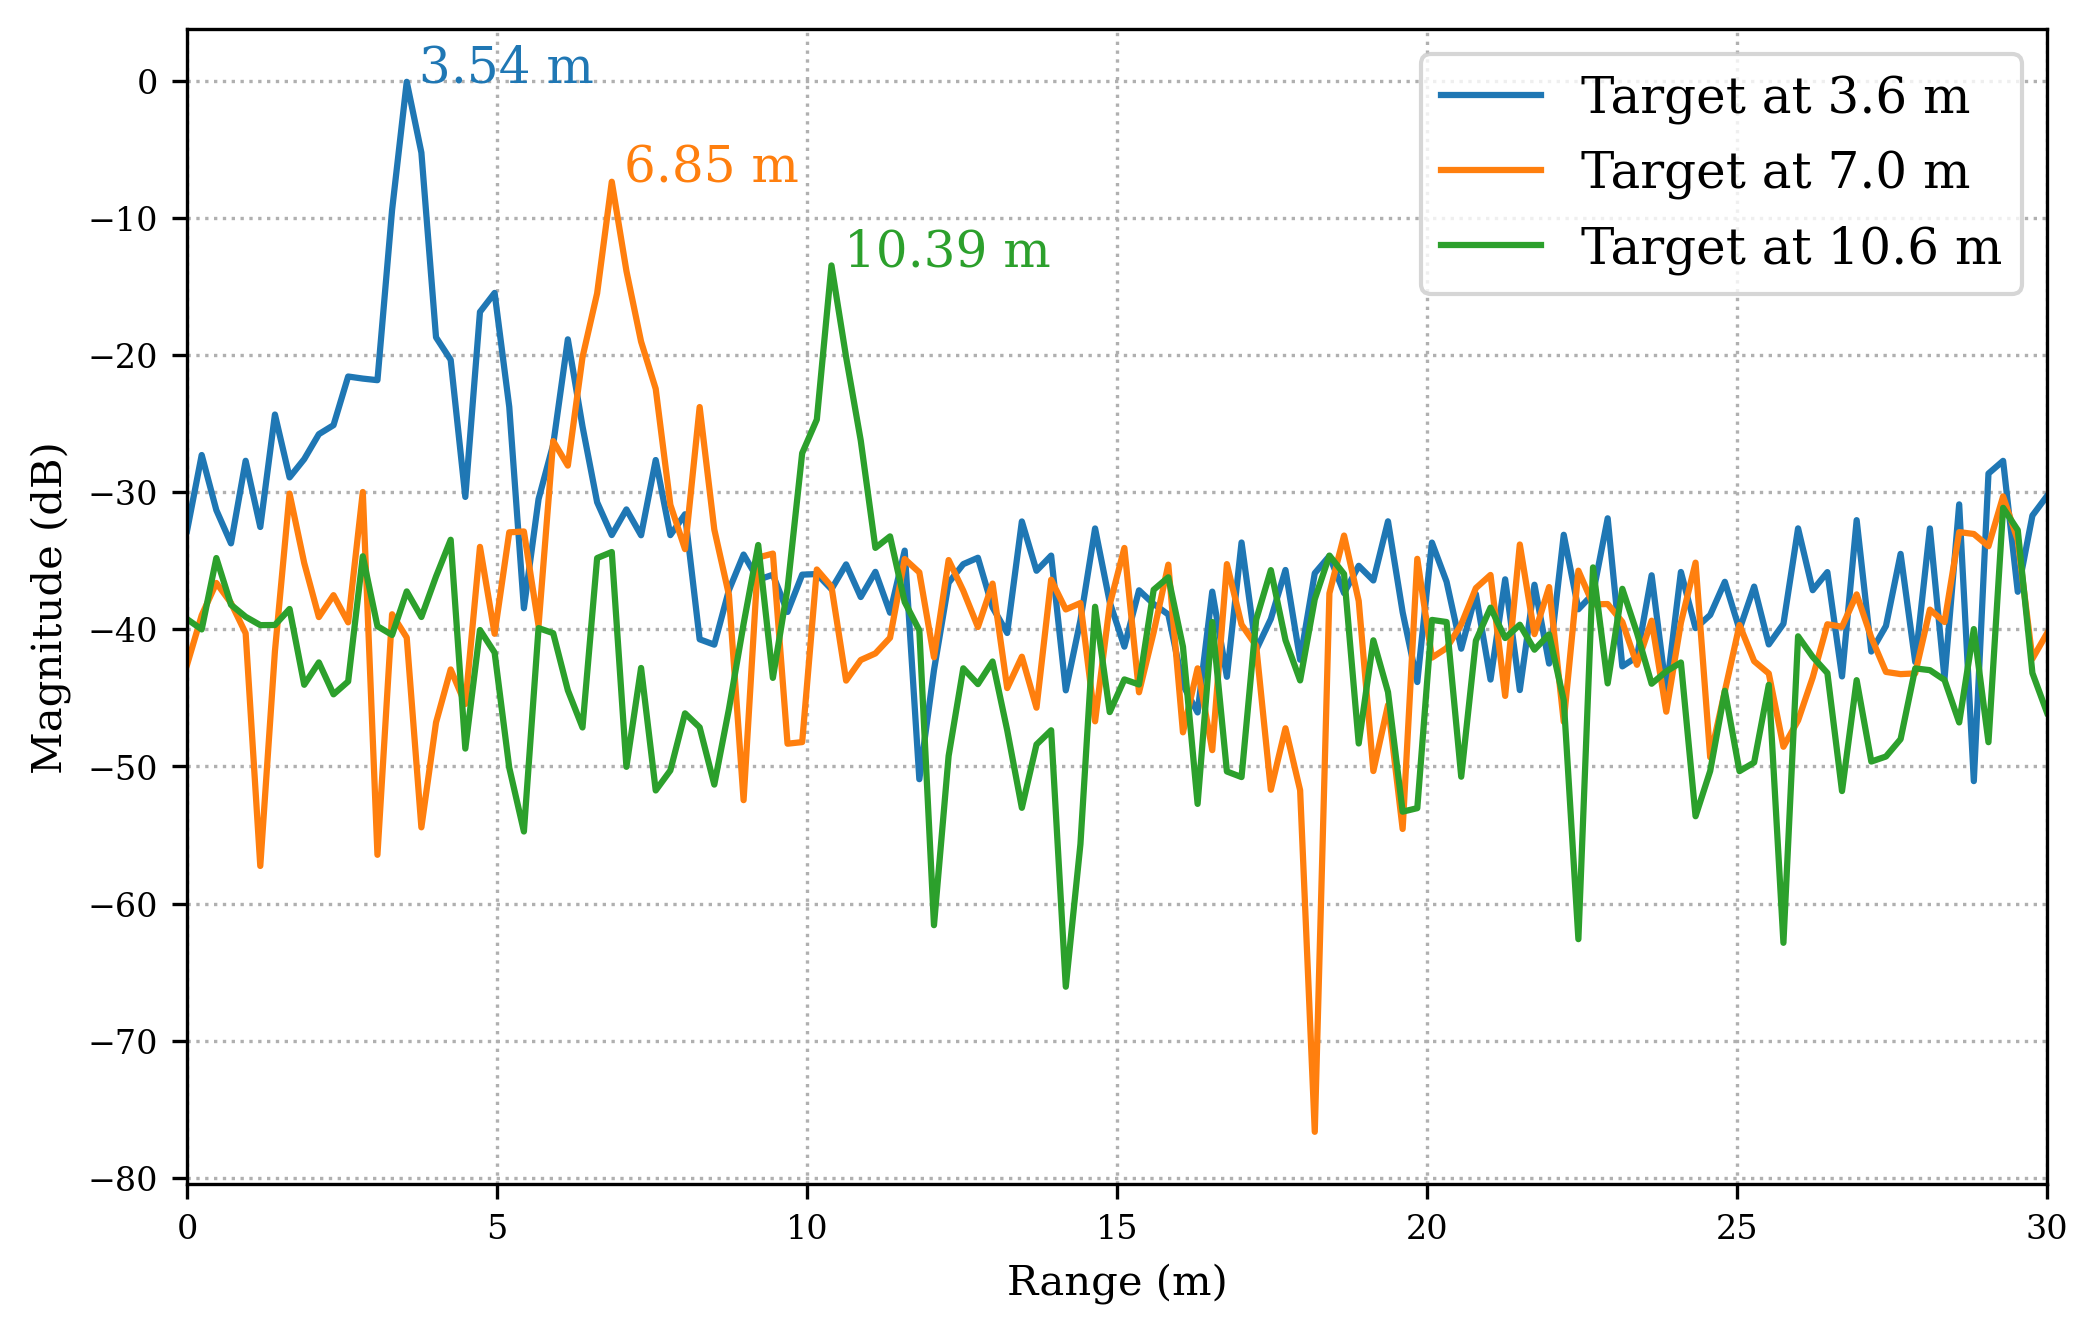

In [5]:
c = 3e8  # Speed of light
max_range = c / (2 * SAMPLING_RATE)
range_axis = np.linspace(0, max_range, num_steps)
target_positions_m = [0, 3.6, 7.0, 10.6]
output_filename = "rangingEx.eps"

plt.figure(figsize=[8,5])

i=1
channel_response_sky_cal = all_channel_response[i] - all_channel_response[0]
a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
print(calculate_snr(a_scan_sky_cal))
ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12)-5
plt.plot(range_axis,ascan_db, label=f'Target at {target_positions_m[i]} m')
peak_index = np.argmax(ascan_db)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range + 0.2, peak_db, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())

for i in range(2,4):
    channel_response_sky_cal = all_channel_response[i] - all_channel_response[0]
    a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
    print(calculate_snr(a_scan_sky_cal))
    ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12)
    plt.plot(range_axis,ascan_db, label=f'Target at {target_positions_m[i]} m')
    peak_index = np.argmax(ascan_db)
    peak_range = range_axis[peak_index]
    peak_db = ascan_db[peak_index]
    plt.text(peak_range + 0.2, peak_db, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())



# --- 5. Finalize and Save Figure ---
#plt.title('Free-Space Ranging Experiment Results')
plt.xlabel('Range (m)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, linestyle=':')
plt.xlim(0, max_range)
#plt.ylim(-60, 5)
plt.legend()

plt.savefig(output_filename, bbox_inches='tight')
print(f"Figure saved as '{output_filename}'")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


signal_power:  0.3075869330005484
average_noise_power:  0.003246908143054023
19.764978792075315
signal_power:  0.04489111364301288
average_noise_power:  0.00013251518772964865
25.29894719929831
Figure saved as 'rangingEx.eps'


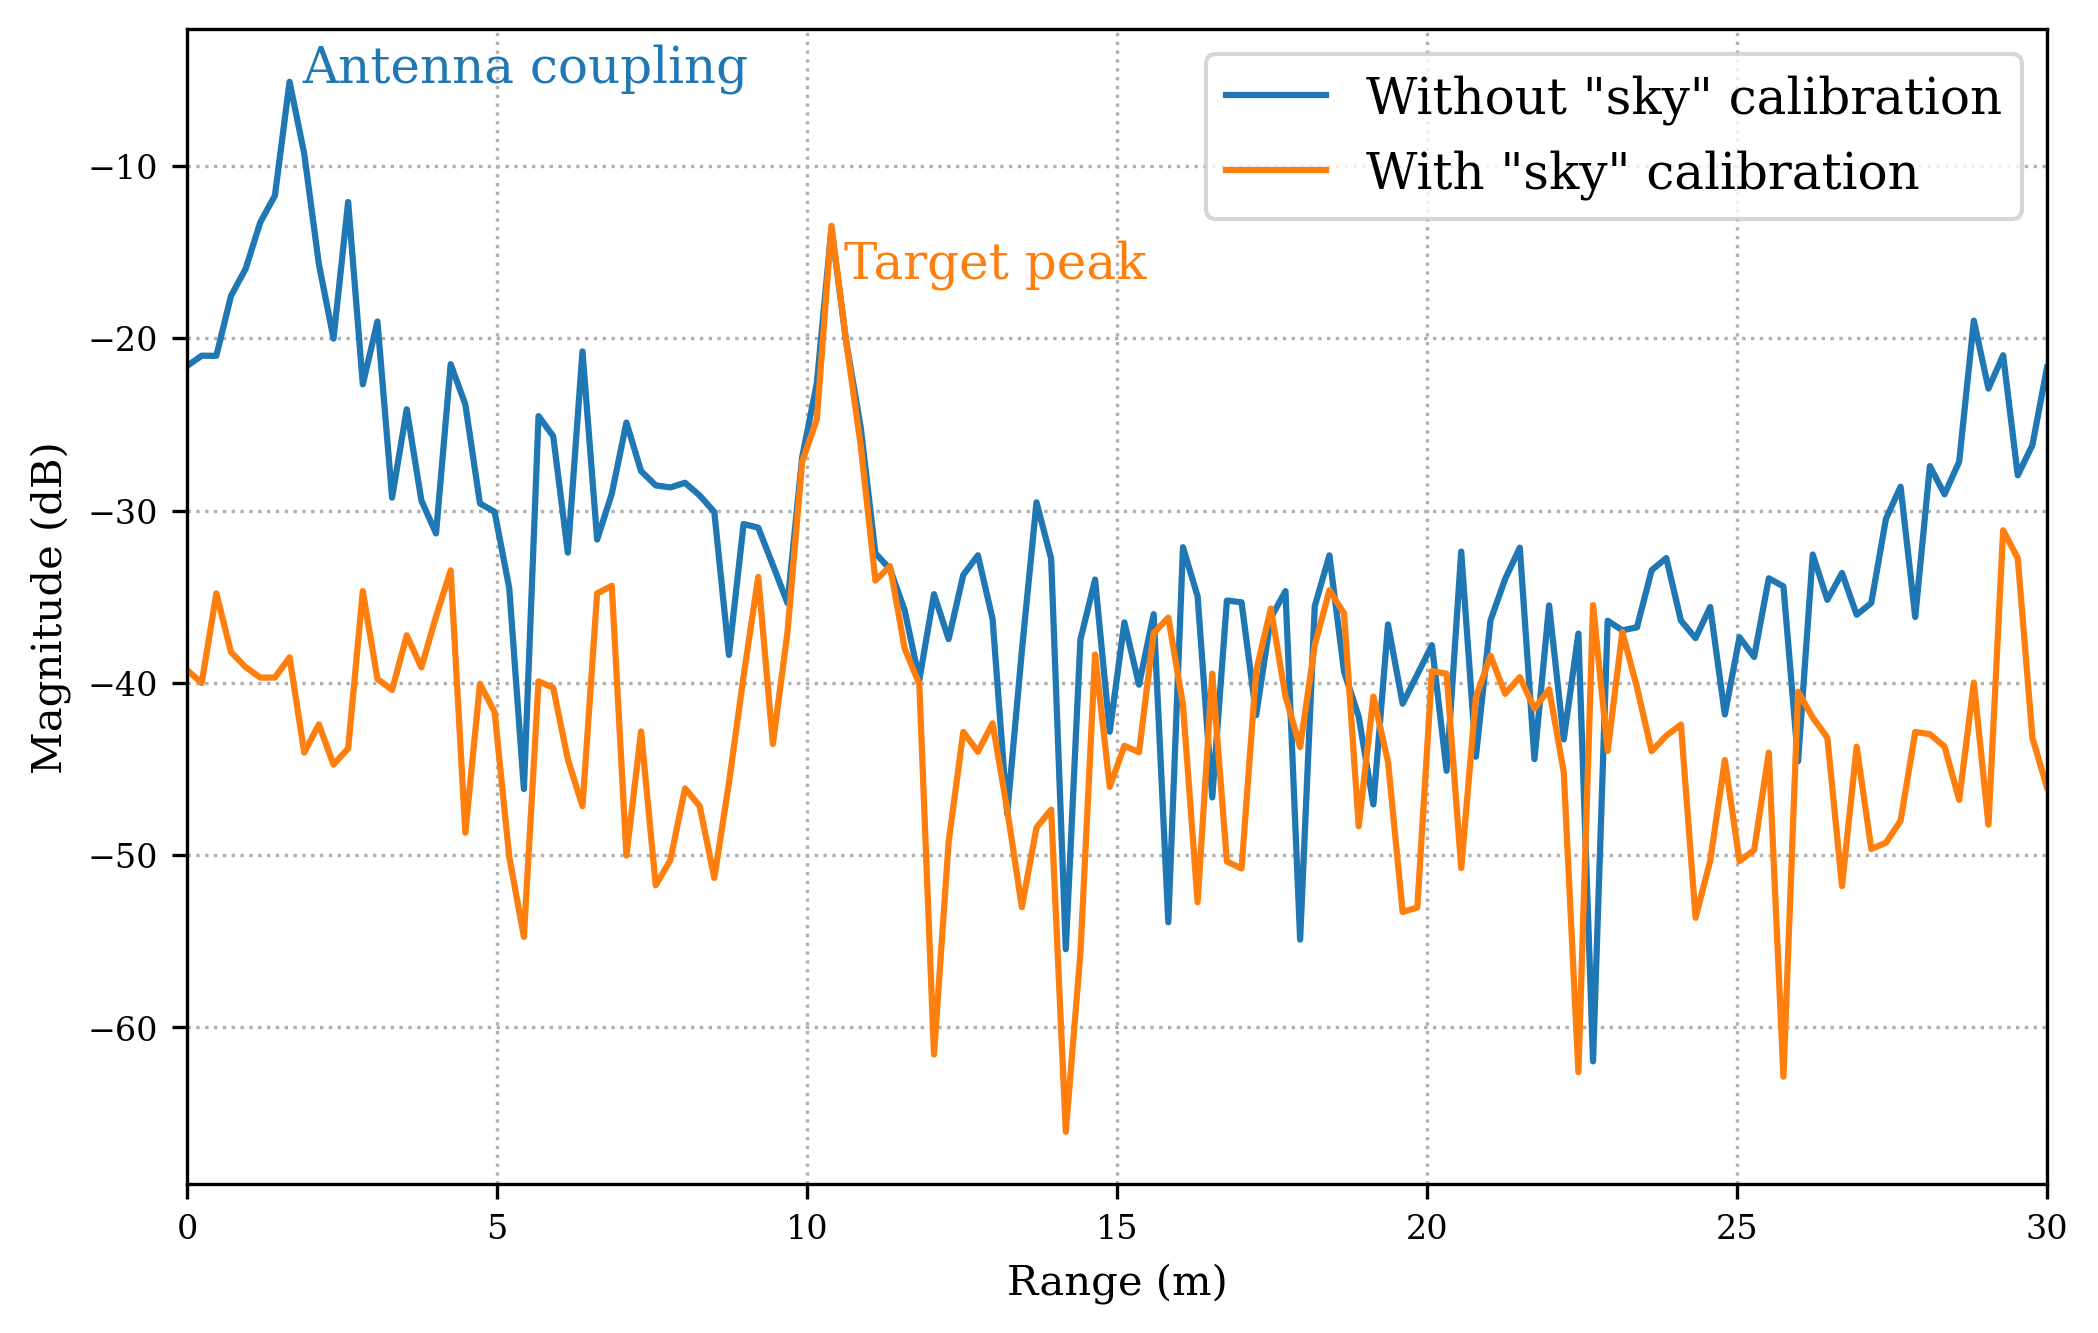

In [6]:
c = 3e8  # Speed of light
max_range = c / (2 * SAMPLING_RATE)
range_axis = np.linspace(0, max_range, num_steps)
output_filename = "rangingEx.eps"

plt.figure(figsize=[8,5])

i=3
channel_response_sky_cal = all_channel_response[i]
a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
print(calculate_snr(a_scan_sky_cal))
ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12)
plt.plot(range_axis,ascan_db, label=f'Without "sky" calibration')
peak_index = np.argmax(ascan_db)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range + 0.2, peak_db, 'Antenna coupling', fontsize=12, color=plt.gca().lines[-1].get_color())

i=3
channel_response_sky_cal = all_channel_response[i] - all_channel_response[0]
a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
print(calculate_snr(a_scan_sky_cal))
ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12)
plt.plot(range_axis,ascan_db, label=f'With "sky" calibration')
peak_index = np.argmax(ascan_db)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range + 0.2, peak_db-3, 'Target peak', fontsize=12, color=plt.gca().lines[-1].get_color())

plt.xlabel('Range (m)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, linestyle=':')
plt.xlim(0, max_range)
#plt.ylim(-60, 5)
plt.legend()

plt.savefig('compareCal.eps', bbox_inches='tight')
print(f"Figure saved as '{output_filename}'")
plt.show()